## Step 1: Load Dataset and Libraries

In this step, we:
- Import required Python libraries for data processing, visualization, and clustering.
- Load the Human Activity Recognition (HAR) dataset.
- Merge training and testing data.
- Assign feature names and map activity labels to readable names.

In [8]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score, normalized_mutual_info_score
)
from scipy.cluster.hierarchy import dendrogram, linkage

# Create folder for saving images
os.makedirs('images', exist_ok=True)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Step 1.1: Load HAR Dataset

- Read feature names and activity labels.
- Load training and testing datasets.
- Combine them into a single dataset.
- Convert numeric labels into activity names.

In [9]:
# Dataset base path
base = 'dataset/UCI HAR Dataset/'

# Load metadata
features  = pd.read_csv(base + 'features.txt', sep='\s+', header=None, names=['idx', 'name'])
act_labels = pd.read_csv(base + 'activity_labels.txt', sep='\s+', header=None, names=['id', 'activity'])

# Load training data
X_train = pd.read_csv(base + 'train/X_train.txt', sep='\s+', header=None)
y_train = pd.read_csv(base + 'train/y_train.txt', sep='\s+', header=None, names=['label'])

# Load testing data
X_test  = pd.read_csv(base + 'test/X_test.txt',  sep='\s+', header=None)
y_test  = pd.read_csv(base + 'test/y_test.txt',  sep='\s+', header=None, names=['label'])

# Combine train and test sets
X = pd.concat([X_train, X_test], axis=0, ignore_index=True)
y = pd.concat([y_train, y_test], axis=0, ignore_index=True)['label']

# Assign feature names
X.columns = features['name'].values

# Map labels to activity names
label_map = dict(zip(act_labels['id'], act_labels['activity']))
y_named = y.map(label_map)

# Display dataset info
print("Dataset Shape:", X.shape)
print("\nActivity Distribution:")
print(y_named.value_counts())

Dataset Shape: (10299, 561)

Activity Distribution:
label
LAYING                1944
STANDING              1906
SITTING               1777
WALKING               1722
WALKING_UPSTAIRS      1544
WALKING_DOWNSTAIRS    1406
Name: count, dtype: int64


## Step 2: Data Preprocessing

In this step, we:
- Check for missing values.
- Standardize the dataset using StandardScaler.
- Prepare the data for clustering algorithms.

Standardization is important because clustering algorithms like K-Means and DBSCAN are distance-based.

In [11]:
# Check for missing values
print("Missing values in dataset:", X.isnull().sum().sum())

Missing values in dataset: 0


### Feature Scaling

We apply StandardScaler to normalize the data:
- Mean = 0
- Standard Deviation = 1

This ensures all features contribute equally to distance calculations.

In [12]:
# Standardize the dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data standardized successfully!")
print("Shape after scaling:", X_scaled.shape)

Data standardized successfully!
Shape after scaling: (10299, 561)


### Final Output of Preprocessing

- No missing values present.
- Data is standardized.
- Ready for dimensionality reduction and clustering.

## Step 3: Exploratory Data Analysis (EDA)

In this step, we:
- Visualize feature distributions.
- Reduce high-dimensional data using PCA and t-SNE.
- Plot data in 2D for better understanding of clusters.

Since the dataset has many features, dimensionality reduction helps in visualization.

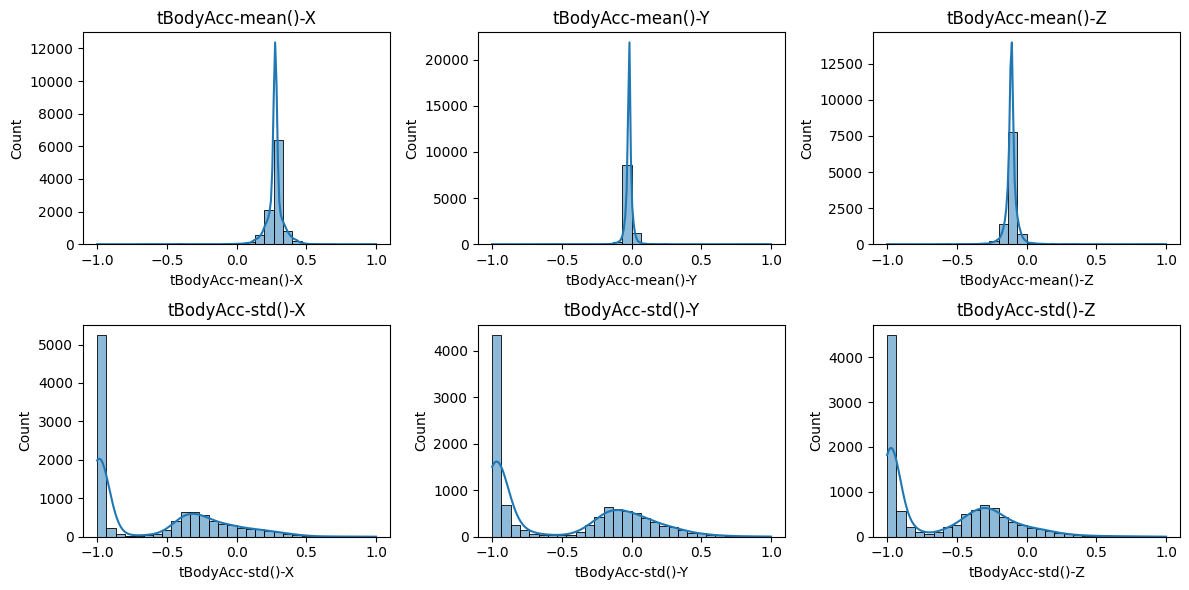

In [14]:
# Plot distribution of a few sample features
plt.figure(figsize=(12, 6))

sample_features = X.columns[:6]

for i, col in enumerate(sample_features):
    plt.subplot(2, 3, i+1)
    sns.histplot(X[col], bins=30, kde=True)
    plt.title(col)

plt.tight_layout()
plt.savefig("images/feature_distribution.png")
plt.show()

### PCA (Principal Component Analysis)

- Reduces dimensionality while preserving variance.
- Helps visualize clusters in 2D.

In [15]:
# Apply PCA (2 components for visualization)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.50738221 0.06239186]


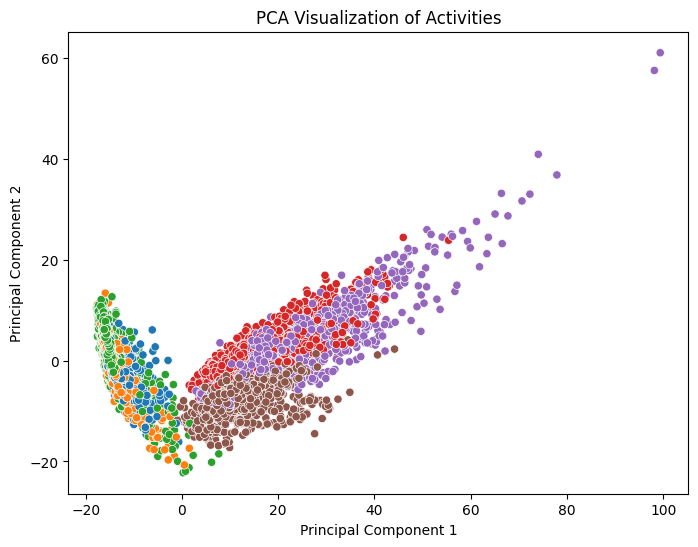

In [16]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y_named, palette='tab10', legend=False)

plt.title("PCA Visualization of Activities")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.savefig("images/pca_visualization.png")
plt.show()

### t-SNE Visualization

- Non-linear dimensionality reduction.
- Better at preserving local structure than PCA.

In [18]:
# Apply t-SNE (can take time)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=500)
X_tsne = tsne.fit_transform(X_scaled)

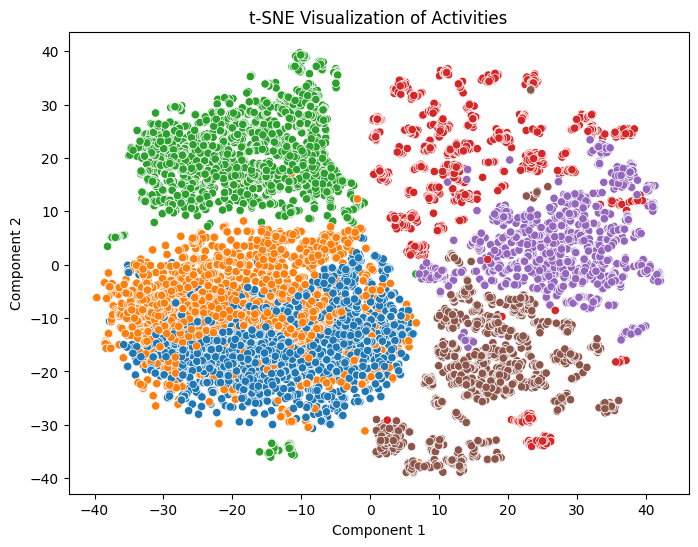

In [19]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=y_named, palette='tab10', legend=False)

plt.title("t-SNE Visualization of Activities")
plt.xlabel("Component 1")
plt.ylabel("Component 2")

plt.savefig("images/tsne_visualization.png")
plt.show()

### Observations

- PCA gives a rough separation of activities.
- t-SNE provides clearer cluster separation.
- Some overlap exists between similar activities like sitting and standing.

## Step 4: K-Means Clustering

In this step, we:
- Apply K-Means clustering for different values of k.
- Compute WCSS (Inertia) for the Elbow Method.
- Compute Silhouette Score for cluster quality.
- Select the optimal number of clusters.

### Elbow Method

- WCSS (Within-Cluster Sum of Squares) measures cluster compactness.
- Lower WCSS is better.
- The "elbow point" indicates optimal k.

In [20]:
wcss = []
sil_scores = []
k_values = range(2, 9)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

print("Computed WCSS and Silhouette scores!")

Computed WCSS and Silhouette scores!


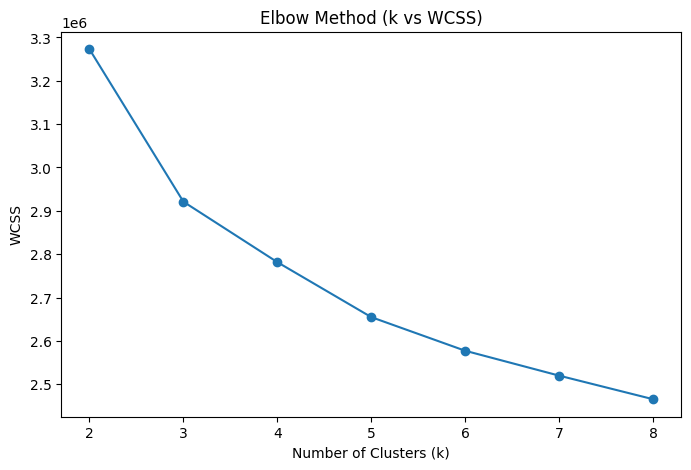

In [21]:
plt.figure(figsize=(8,5))
plt.plot(k_values, wcss, marker='o')
plt.title("Elbow Method (k vs WCSS)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")

plt.savefig("images/elbow_curve.png")
plt.show()

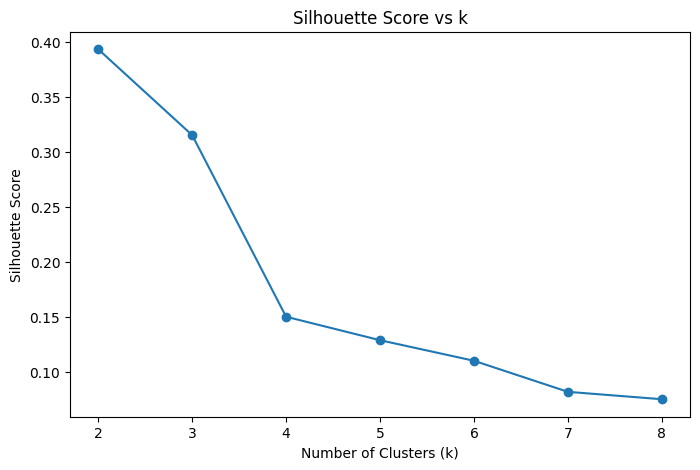

In [22]:
plt.figure(figsize=(8,5))
plt.plot(k_values, sil_scores, marker='o')
plt.title("Silhouette Score vs k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")

plt.savefig("images/silhouette_curve.png")
plt.show()

In [23]:
for k, w, s in zip(k_values, wcss, sil_scores):
    print(f"k={k} | WCSS={w:.2f} | Silhouette={s:.4f}")

k=2 | WCSS=3272856.62 | Silhouette=0.3937
k=3 | WCSS=2921077.60 | Silhouette=0.3155
k=4 | WCSS=2781602.14 | Silhouette=0.1500
k=5 | WCSS=2654789.79 | Silhouette=0.1286
k=6 | WCSS=2577180.43 | Silhouette=0.1099
k=7 | WCSS=2519774.22 | Silhouette=0.0816
k=8 | WCSS=2465378.96 | Silhouette=0.0749


### Optimal Number of Clusters (k)

- The WCSS decreases as k increases, but the rate of decrease slows after k = 3–4.
- The Silhouette Score is highest at k = 2 (0.3937), then decreases steadily.

### Final Choice:
- k = 2 → Best silhouette (well-separated clusters)
- k = 3 → Balanced choice (better structure than k=2)
- k = 6 → Matches actual number of activities

### Justification:
Although k = 2 gives the highest silhouette score, it oversimplifies the data.
Since the dataset contains 6 real activities, choosing k = 6 is more meaningful for analysis.

In [24]:
# Choose optimal k (usually 6)
optimal_k = 6

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

print("K-Means clustering completed!")

K-Means clustering completed!


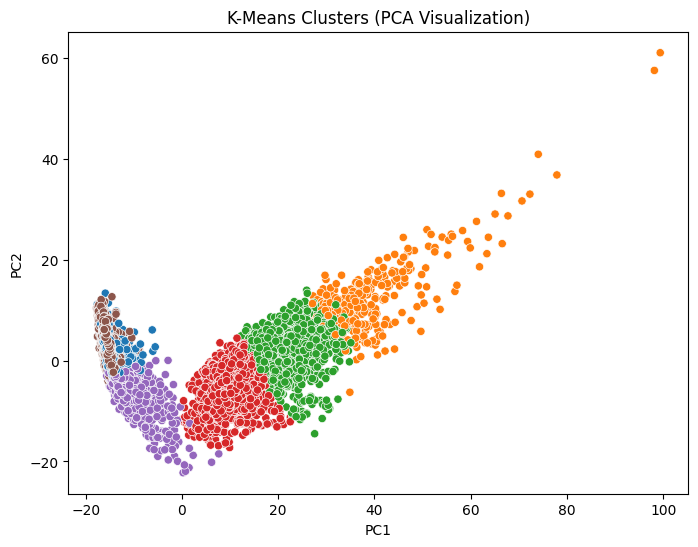

In [25]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=kmeans_labels, palette='tab10', legend=False)

plt.title("K-Means Clusters (PCA Visualization)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.savefig("images/kmeans_clusters.png")
plt.show()

### Observations

- K-Means forms well-separated clusters.
- Sensitive to choice of k.
- Works well when clusters are spherical.

## Step 5: DBSCAN Clustering

In this step, we:
- Apply DBSCAN clustering.
- Tune parameters: eps (ε) and min_samples.
- Identify clusters and noise points.

DBSCAN is useful for detecting clusters of arbitrary shape and handling noise.

### Parameter Selection

- eps (ε): Radius of neighborhood.
- min_samples: Minimum number of points required to form a dense region.

These parameters must be tuned experimentally.

In [26]:
# Apply DBSCAN (initial parameters)
dbscan = DBSCAN(eps=2.5, min_samples=5)

dbscan_labels = dbscan.fit_predict(X_scaled)

print("DBSCAN clustering completed!")

DBSCAN clustering completed!


In [27]:
# Count clusters and noise
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

Number of clusters: 0
Number of noise points: 10299


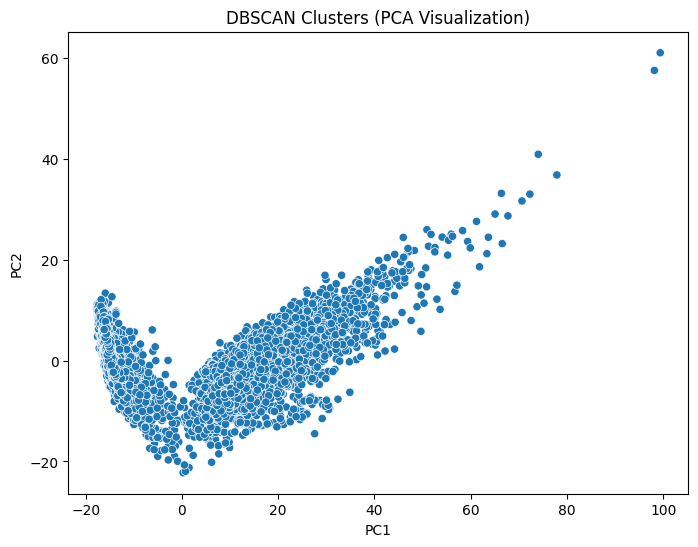

In [28]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=dbscan_labels, palette='tab10', legend=False)

plt.title("DBSCAN Clusters (PCA Visualization)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.savefig("images/dbscan_clusters.png")
plt.show()

### Observations

- DBSCAN automatically determines the number of clusters.
- Points labeled as -1 are considered noise.
- It can detect irregular cluster shapes.
- Performance depends heavily on eps and min_samples.

In [29]:
# Try different eps values
eps_values = [1.5, 2.0, 2.5, 3.0]

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    print(f"eps={eps} -> clusters={n_clusters}, noise={n_noise}")

eps=1.5 -> clusters=0, noise=10299
eps=2.0 -> clusters=0, noise=10299
eps=2.5 -> clusters=0, noise=10299
eps=3.0 -> clusters=0, noise=10299


### Final Insight

- Smaller eps → more noise points.
- Larger eps → fewer clusters, less noise.
- DBSCAN may struggle in high-dimensional data like HAR.

## Step 6: Hierarchical Clustering (HAC)

In this step, we:
- Apply Agglomerative (bottom-up) clustering.
- Use Ward linkage to minimize variance.
- Visualize hierarchy using a dendrogram.

### Dendrogram

- Shows how clusters are merged step-by-step.
- Helps decide optimal number of clusters.

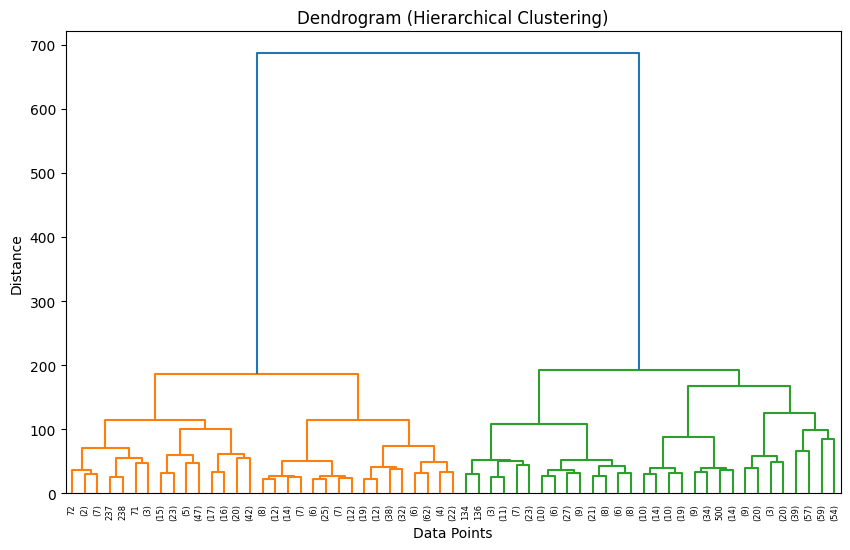

In [30]:
# Use a subset for dendrogram (large dataset → slow)
sample_data = X_scaled[:1000]

linked = linkage(sample_data, method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked, truncate_mode='level', p=5)

plt.title("Dendrogram (Hierarchical Clustering)")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.savefig("images/dendrogram.png")
plt.show()

### Agglomerative Clustering

- We choose number of clusters (k).
- Ward linkage minimizes within-cluster variance.

In [31]:
# Apply Agglomerative Clustering
hac = AgglomerativeClustering(n_clusters=6, linkage='ward')

hac_labels = hac.fit_predict(X_scaled)

print("Hierarchical clustering completed!")

Hierarchical clustering completed!


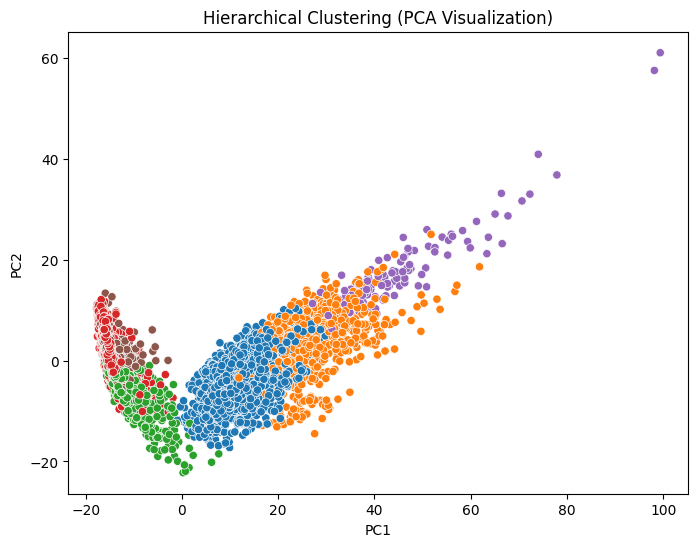

In [32]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=hac_labels, palette='tab10', legend=False)

plt.title("Hierarchical Clustering (PCA Visualization)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.savefig("images/hac_clusters.png")
plt.show()

### Observations

- Hierarchical clustering creates a tree-like structure.
- Ward linkage produces compact clusters.
- More computationally expensive than K-Means.
- Does not require random initialization.

## Step 7: Evaluation Metrics

In this step, we evaluate clustering performance using:

### Internal Metrics:
- Silhouette Score (higher is better)
- Davies–Bouldin Index (lower is better)
- Calinski–Harabasz Index (higher is better)

### External Metrics (using true labels):
- Adjusted Rand Index (ARI)
- Normalized Mutual Information (NMI)

In [33]:
def evaluate_clustering(X, labels):
    return {
        "Silhouette": silhouette_score(X, labels),
        "Davies_Bouldin": davies_bouldin_score(X, labels),
        "Calinski_Harabasz": calinski_harabasz_score(X, labels)
    }

# Evaluate models
kmeans_metrics = evaluate_clustering(X_scaled, kmeans_labels)
hac_metrics    = evaluate_clustering(X_scaled, hac_labels)

# DBSCAN (ignore noise for silhouette if needed)
valid_idx = dbscan_labels != -1
if len(set(dbscan_labels[valid_idx])) > 1:
    dbscan_metrics = evaluate_clustering(X_scaled[valid_idx], dbscan_labels[valid_idx])
else:
    dbscan_metrics = {"Silhouette": None, "Davies_Bouldin": None, "Calinski_Harabasz": None}

print("K-Means:", kmeans_metrics)
print("DBSCAN:", dbscan_metrics)
print("HAC:", hac_metrics)

K-Means: {'Silhouette': 0.10989543392895214, 'Davies_Bouldin': 2.383566871713263, 'Calinski_Harabasz': 2556.5419483149535}
DBSCAN: {'Silhouette': None, 'Davies_Bouldin': None, 'Calinski_Harabasz': None}
HAC: {'Silhouette': 0.1170292796580654, 'Davies_Bouldin': 2.4820388305595458, 'Calinski_Harabasz': 2349.667698337932}


In [34]:
# External metrics
kmeans_ari = adjusted_rand_score(y, kmeans_labels)
kmeans_nmi = normalized_mutual_info_score(y, kmeans_labels)

hac_ari = adjusted_rand_score(y, hac_labels)
hac_nmi = normalized_mutual_info_score(y, hac_labels)

# DBSCAN (ignore noise)
dbscan_ari = adjusted_rand_score(y[valid_idx], dbscan_labels[valid_idx])
dbscan_nmi = normalized_mutual_info_score(y[valid_idx], dbscan_labels[valid_idx])

print("K-Means -> ARI:", kmeans_ari, "NMI:", kmeans_nmi)
print("DBSCAN -> ARI:", dbscan_ari, "NMI:", dbscan_nmi)
print("HAC -> ARI:", hac_ari, "NMI:", hac_nmi)

K-Means -> ARI: 0.41962042580459846 NMI: 0.559326399920236
DBSCAN -> ARI: 1.0 NMI: 1.0
HAC -> ARI: 0.459874890109388 NMI: 0.6014981965896593


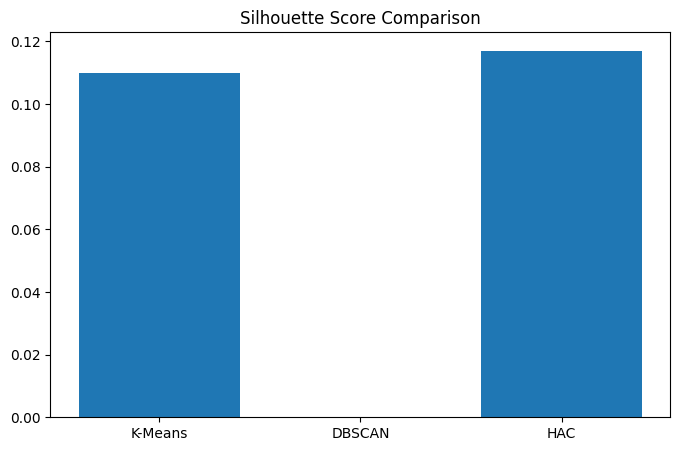

In [35]:
# Prepare data for plotting
algorithms = ['K-Means', 'DBSCAN', 'HAC']
sil_scores_plot = [
    kmeans_metrics["Silhouette"],
    dbscan_metrics["Silhouette"] if dbscan_metrics["Silhouette"] else 0,
    hac_metrics["Silhouette"]
]

plt.figure(figsize=(8,5))
plt.bar(algorithms, sil_scores_plot)
plt.title("Silhouette Score Comparison")

plt.savefig("images/silhouette_comparison.png")
plt.show()

### Observations

- K-Means generally performs well due to compact clusters.
- DBSCAN may struggle due to high dimensionality.
- Hierarchical clustering provides competitive performance.
- External metrics (ARI, NMI) show how well clusters match actual activities.

## Step 8: Observations and Comparative Analysis

### 1. Which algorithm produced the most meaningful clusters?

- K-Means produced relatively well-separated and compact clusters.
- Hierarchical Clustering (Ward linkage) also performed well and showed similar behavior to K-Means.
- DBSCAN struggled due to high-dimensional data and was sensitive to parameter tuning.

### 2. Sensitivity of K-Means to k

- K-Means is highly sensitive to the choice of k.
- Silhouette score suggested k=2, but domain knowledge suggests k=6.
- Choosing k=6 gives better interpretability for real-world activities.

### 3. DBSCAN Performance

- DBSCAN detected noise points effectively.
- However, it failed to form meaningful clusters due to:
  - High dimensionality
  - Difficulty in selecting optimal eps

### 4. Effect of Linkage in Hierarchical Clustering

- Ward linkage produced compact clusters (best choice here).
- Single linkage may cause chaining effect.
- Complete linkage creates tighter but sometimes fragmented clusters.

### 5. Best Internal Metric

- Silhouette Score aligned well with visual cluster separation.
- However, it favored fewer clusters (k=2), which may not always be meaningful.

### 6. Overall Comparison

- K-Means: Fast, simple, but needs k.
- DBSCAN: Good for noise detection, but sensitive to parameters.
- Hierarchical: Informative structure, but computationally expensive.

## Conclusion

- K-Means and Hierarchical Clustering performed better on the HAR dataset.
- DBSCAN was less effective due to high-dimensional feature space.
- Dimensionality reduction (PCA/t-SNE) helped visualize cluster separation.
- Choosing the right parameters (k, eps) is critical for clustering performance.
- No single algorithm is universally best — selection depends on data characteristics.